<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/mnits_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load Data
Goal: Load the MNIST dataset from the CSV into a Pandas DataFrame.
Explanation: Same as before. The dataset has id, class (labels 0-9), and 784 pixel columns.

In [2]:
import pandas as pd

# Load the dataset (adjust path as needed, e.g., 'mnist.csv')
df = pd.read_csv('mnist.csv')

# Quick inspection
print("Dataset shape:", df.shape)
print("\nFirst few rows:\n", df.head())
print("\nColumn names:\n", df.columns)
print("\nData types:\n", df.dtypes)

Dataset shape: (4000, 786)

First few rows:
       id  class  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0  31953      5       0       0       0       0       0       0       0   
1  34452      8       0       0       0       0       0       0       0   
2  60897      5       0       0       0       0       0       0       0   
3  36953      0       0       0       0       0       0       0       0   
4   1981      3       0       0       0       0       0       0       0   

   pixel8  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pi

2. Explore (EDA)
Goal: Perform Exploratory Data Analysis to understand the data.
Explanation: Identical to before—check class balance, pixel stats, and visualize digits. This confirms the data suits SVM (high-dimensional, but separable with kernels).


Class distribution:
 class
0    376
1    486
2    390
3    417
4    369
5    363
6    391
7    426
8    416
9    366
Name: count, dtype: int64

Pixel value stats:
        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
count  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0   
mean      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
std       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
min       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
25%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
50%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
75%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

       pixel10  ...     pixel775     pixel776     pixel777     pixel778  \
count   4000.0  ...  4000.0000

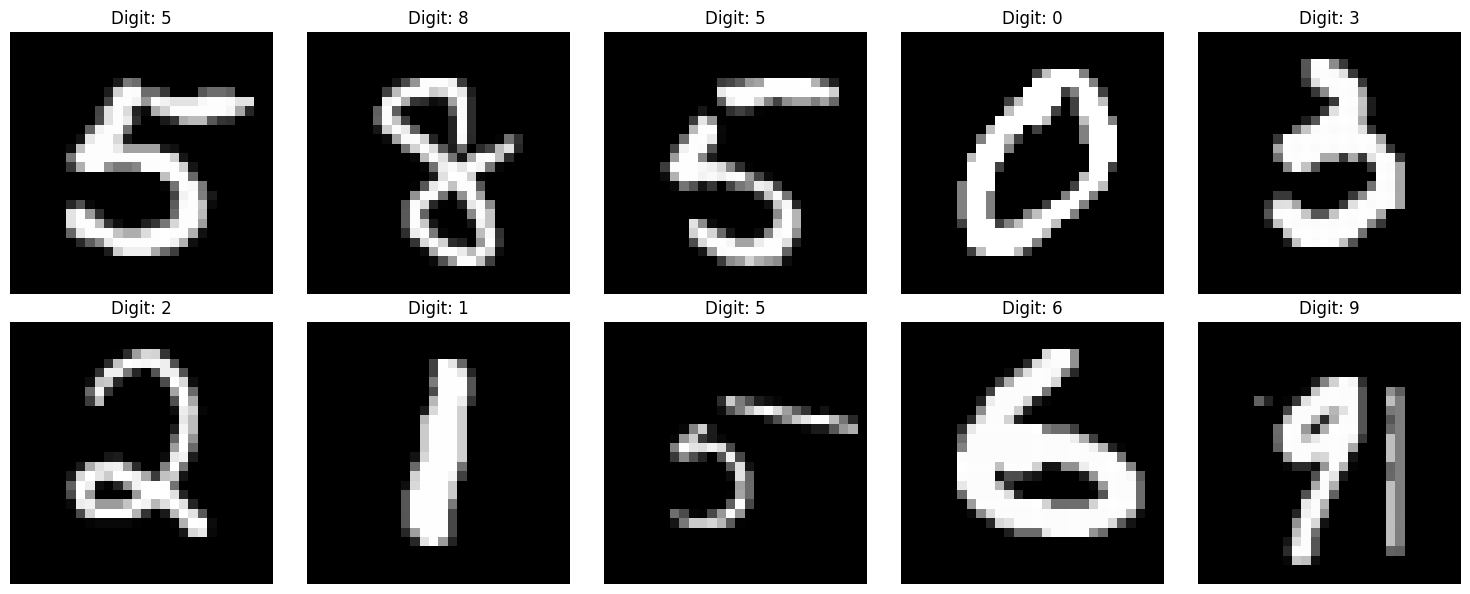


Missing values:
 0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
print("\nClass distribution:\n", df['class'].value_counts().sort_index())

# Pixel value statistics
print("\nPixel value stats:\n", df.iloc[:, 2:].describe())  # Exclude id, class

# Visualize a few images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img = df.iloc[i, 2:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Digit: {df.iloc[i, 1]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Check for missing values
print("\nMissing values:\n", df.isna().sum().sum())

3. Handle Missing Values
Goal: Address any missing values.
Explanation: MNIST is clean, so no changes. If any missing, fill pixels with 0.
Code:

In [4]:
# Check for missing values
missing = df.isna().sum()
print("Missing values per column:\n", missing[missing > 0])

# If missing (unlikely), fill pixel columns with 0
if df.isna().sum().sum() > 0:
    df.iloc[:, 2:] = df.iloc[:, 2:].fillna(0)
    print("Missing pixel values filled with 0")

Missing values per column:
 Series([], dtype: int64)


4. Feature Engineering
Goal: Modify or create features for better performance.
Explanation: Unlike Naive Bayes, SVM can be slow on 784 features due to computational complexity (O(n^2) for training). We'll add Principal Component Analysis (PCA) to reduce dimensions while retaining ~95% variance (e.g., to ~100-200 components). This speeds up SVM without much accuracy loss. Binarization isn't needed for SVM.

Original features: 784
Reduced features: 148
Explained variance ratio sum: 0.9502135870442442


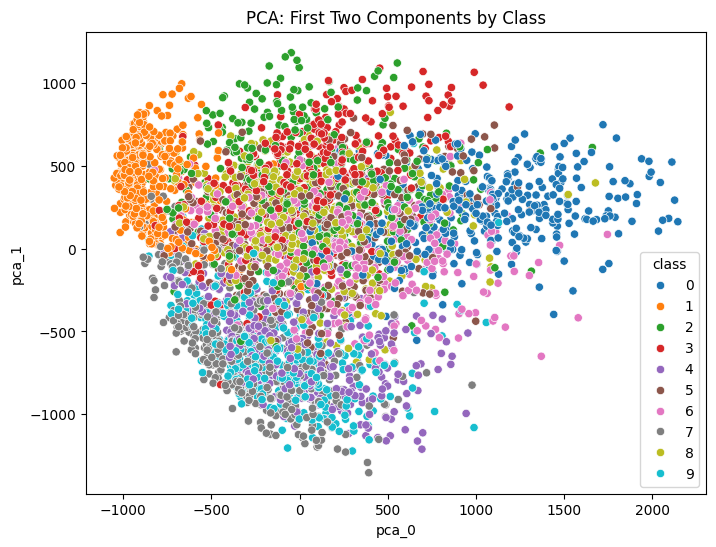

In [5]:
from sklearn.decomposition import PCA
import numpy as np

# Features (pixels) before split
X = df.drop(['id', 'class'], axis=1)

# Apply PCA (fit on full data for simplicity, but in practice fit only on train)
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X)

# Update df with PCA features (for exploration)
pca_df = pd.DataFrame(X_pca, columns=[f'pca_{i}' for i in range(X_pca.shape[1])])
pca_df['class'] = df['class']

print("Original features:", X.shape[1])
print("Reduced features:", X_pca.shape[1])
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

# Visualize first two PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_df['pca_0'], y=pca_df['pca_1'], hue=pca_df['class'], palette='tab10')
plt.title("PCA: First Two Components by Class")
plt.show()

5. Train/Test Split
Goal: Split into training and test sets.
Explanation: Same as before—80/20 split, stratified by class.

In [6]:
from sklearn.model_selection import train_test_split

# Set random seed
np.random.seed(42)

# Features and labels
X = df.drop(['id', 'class'], axis=1)
y = df['class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (3200, 784)
Test features shape: (800, 784)


6. Preprocessing (OneHot + Scaling)
Goal: Apply OneHot encoding and scaling.
Explanation: OneHot unnecessary for labels (SVM uses integers). For scaling, use StandardScaler (mean=0, std=1) as SVM is sensitive to feature scales. Apply PCA here (fit on train, transform both) for dimensionality reduction.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Create preprocessing pipeline
preprocess = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('pca', PCA(n_components=0.95))  # Reduce to 95% variance
])

# Fit on train, transform both
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre = preprocess.transform(X_test)

print("Preprocessed train shape:", X_train_pre.shape)
print("Preprocessed test shape:", X_test_pre.shape)

Preprocessed train shape: (3200, 245)
Preprocessed test shape: (800, 245)


7. Train SVM
Goal: Train an SVM model.
Explanation: Use SVC with RBF kernel (good for non-linear MNIST data). For multiclass, default is one-vs-one

In [8]:
from sklearn.svm import SVC

# Train SVM (RBF kernel, default C=1)
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_pre, y_train)

print("SVM trained.")

SVM trained.


8. Evaluate
Goal: Assess performance on test set.
Explanation: Use accuracy, classification report, and confusion matrix.

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
svm_predictions = svm.predict(X_test_pre)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Test Accuracy: {svm_accuracy * 100:.2f}%")

# Detailed metrics
print("\nSVM Classification Report:\n", classification_report(y_test, svm_predictions))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, svm_predictions))

SVM Test Accuracy: 91.75%

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        70
           1       0.95      0.97      0.96       100
           2       0.75      0.90      0.82        73
           3       0.94      0.91      0.92        86
           4       0.88      0.96      0.92        80
           5       0.89      0.89      0.89        64
           6       0.99      0.89      0.94        90
           7       0.98      0.94      0.96        67
           8       0.92      0.86      0.89        94
           9       0.92      0.86      0.88        76

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800


SVM Confusion Matrix:
 [[70  0  0  0  0  0  0  0  0  0]
 [ 0 97  1  1  0  0  0  0  1  0]
 [ 1  2 66  1  2  0  0  0  1  0]
 [ 0  0  3 78  1  2  0  1  1  0]
 [ 0  0  0  0 77  0  1  0  1  

9. Tune Hyperparameters
Goal: Optimize SVM via grid search.
Explanation: Key params: C (regularization), gamma (kernel width), kernel. Use CV.

In [10]:
from sklearn.model_selection import GridSearchCV

# Param grid (focus on RBF)
param_grid = {
    'kernel': ['rbf'],  # Or add 'linear'
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.001, 0.01]
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy')  # 3-fold CV for speed
grid.fit(X_train_pre, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_ * 100)

# Test best model
best_svm = grid.best_estimator_
print("Best SVM test accuracy:", accuracy_score(y_test, best_svm.predict(X_test_pre)) * 100)

Best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV accuracy: 92.56253762162738
Best SVM test accuracy: 93.375


10Inspect Coefficients
Goal: Examine model parameters.
Explanation: For RBF kernel, no direct coef_ (non-linear). Inspect support vectors, dual coefficients, and n_support per class. For linear kernel, coef_ gives feature weights. Visualize support vectors as images.

Number of support vectors per class: [114  94 181 197 153 207 130 172 183 169]
Total support vectors: 1600


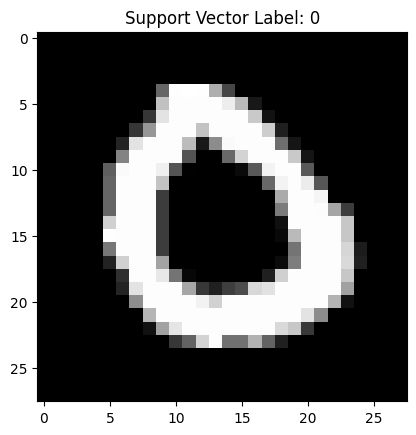

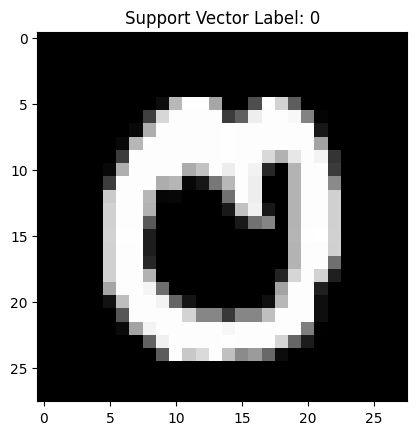

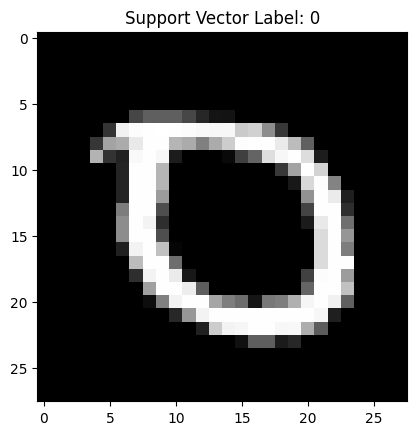

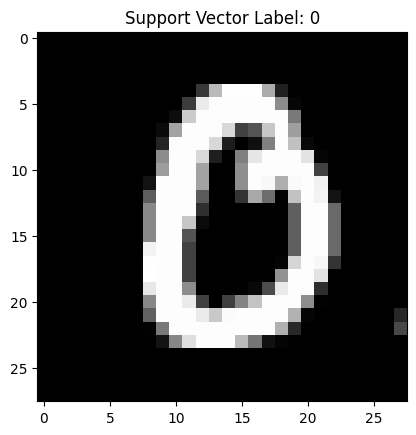

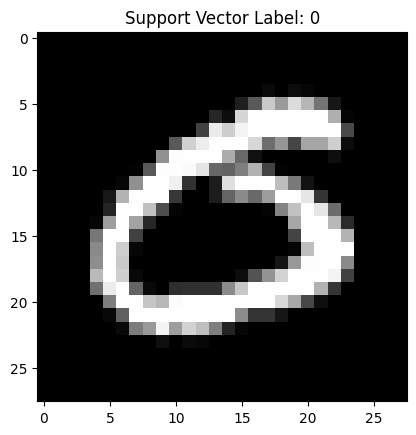

In [11]:
# Support vectors
print("Number of support vectors per class:", best_svm.n_support_)
print("Total support vectors:", best_svm.support_vectors_.shape[0])

# If using linear kernel (retrain if needed):
# linear_svm = SVC(kernel='linear').fit(X_train_pre, y_train)
# print("Linear coef shape:", linear_svm.coef_.shape)  # (45, n_features) for one-vs-one (10 choose 2 = 45)

# Visualize a few support vectors (inverse transform if PCA)
support_indices = best_svm.support_[:5]  # First 5 support vector indices
for idx in support_indices:
    # Inverse PCA and scale if needed; here assume original for viz
    img = X_train.iloc[idx].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Support Vector Label: {y_train.iloc[idx]}")
    plt.show()